In [1]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [2]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [3]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [4]:
# Get date, volume, price, log return for a ticker

pltr_df = get_data('PLTR', size='full', date_filter='2021-01-01')
pltr_df = pltr_df[pltr_df['Date'] <= pd.to_datetime('2026-01-01')]
returns_df = calculate_returns(pltr_df, frequency=1).rename(columns={'Adj Close': 'Price'})
returns_df

,Date,Ticker,Volume,Price,Log Return
1,2021-01-05,PLTR,29050437,24.60,0.051293
2,2021-01-06,PLTR,32732892,23.54,-0.044045
3,2021-01-07,PLTR,32240048,25.00,0.060175
4,2021-01-08,PLTR,41313824,25.20,0.007968
5,2021-01-11,PLTR,32608983,25.93,0.028557
...,...,...,...,...,...
1250,2025-12-24,PLTR,11710125,194.17,0.000206
1251,2025-12-26,PLTR,26261988,188.71,-0.028523
1252,2025-12-29,PLTR,28242003,184.18,-0.024298
1253,2025-12-30,PLTR,23336307,180.84,-0.018301


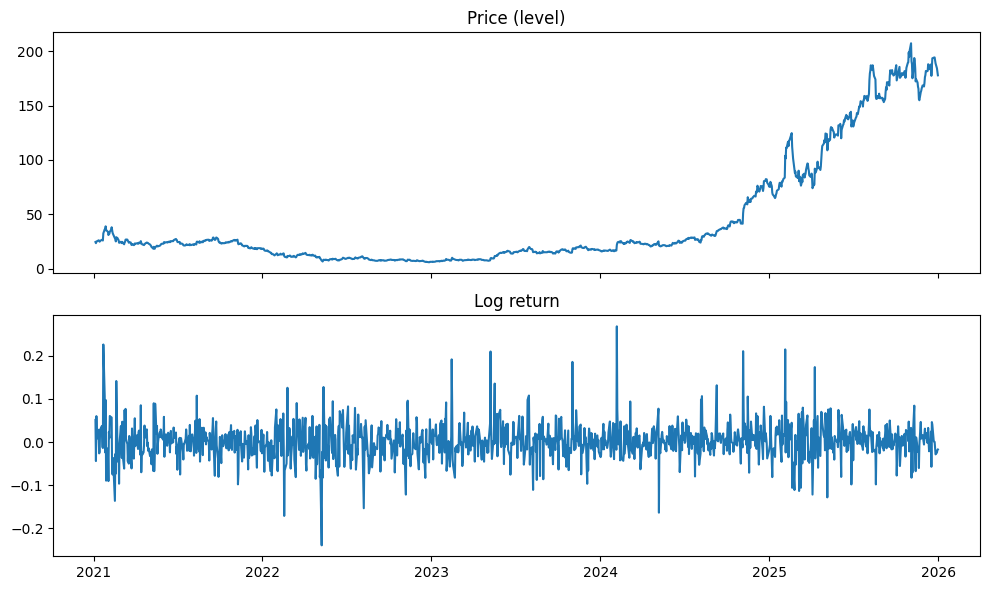

In [5]:
# plot the price, and daily log return, over time

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(returns_df['Date'], returns_df['Price'])
axes[0].set_title('Price (level)')
axes[1].plot(returns_df['Date'], returns_df['Log Return'])
axes[1].set_title('Log return')
plt.tight_layout()

<Axes: xlabel='Date'>

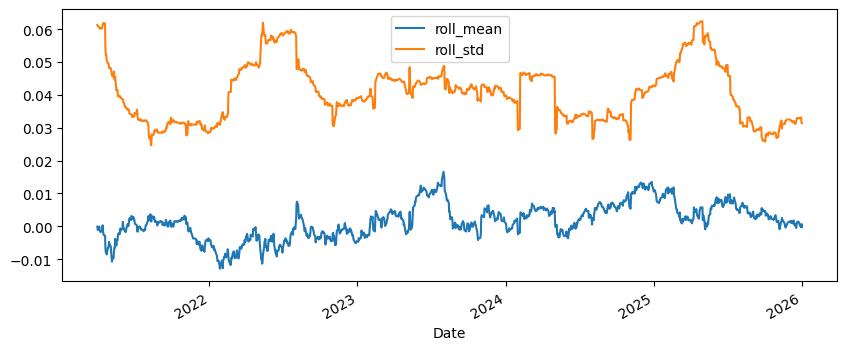

In [6]:
# plot the rolling mean and standard deviation of the log return over w periods
w = 60
r = returns_df['Log Return']
returns_df.assign(
    roll_mean=r.rolling(w).mean(),
    roll_std=r.rolling(w).std()
).plot(x='Date', y=['roll_mean', 'roll_std'], figsize=(10, 4))

In [7]:
# Use the ADF test to check for stationarity

for col in ['Price', 'Log Return']:
    stat, p, *_ = adfuller(returns_df[col].dropna())
    print(f"{col}: ADF stat={stat:.3f}, p-value={p:.4f}")

Price: ADF stat=3.095, p-value=1.0000
Log Return: ADF stat=-19.686, p-value=0.0000


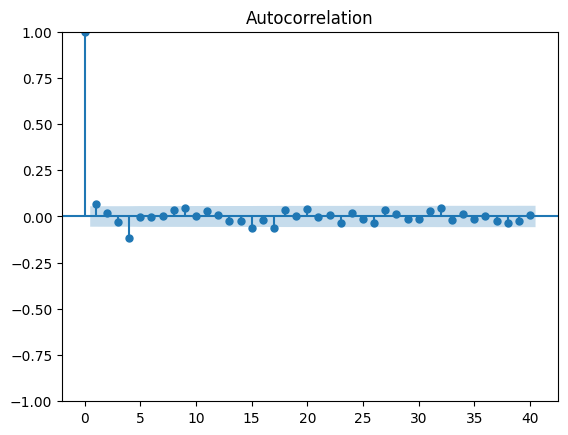

In [8]:
# plot the autocorrelation function of the log return
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(returns_df['Log Return'].dropna(), lags=40)
plt.show()

In [9]:
from arch import arch_model

r = returns_df['Log Return'].dropna() * 100   # percent log returns (arch convention)

model = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
result = model.fit(disp='off')
print(result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Log Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3450.89
Distribution:      Standardized Student's t   AIC:                           6911.78
Method:                  Maximum Likelihood   BIC:                           6937.45
                                              No. Observations:                 1254
Date:                      Sun, May 31 2026   Df Residuals:                     1253
Time:                              13:25:34   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [ ]:
# Ljung-Box: did GARCH(1,1) leave autocorrelation in vol? (requires `result` above)
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

sq_std_resid = (result.std_resid.dropna() ** 2)

lb = acorr_ljungbox(sq_std_resid, lags=[10, 20], return_df=True)
print("Ljung-Box on squared standardized residuals")
print("(H0: no autocorrelation — if p > 0.05, vol dynamics look adequately captured)\n")
print(lb)

fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(sq_std_resid, lags=40, ax=ax)
ax.set_title('ACF of squared standardized residuals')
plt.tight_layout()
plt.show()

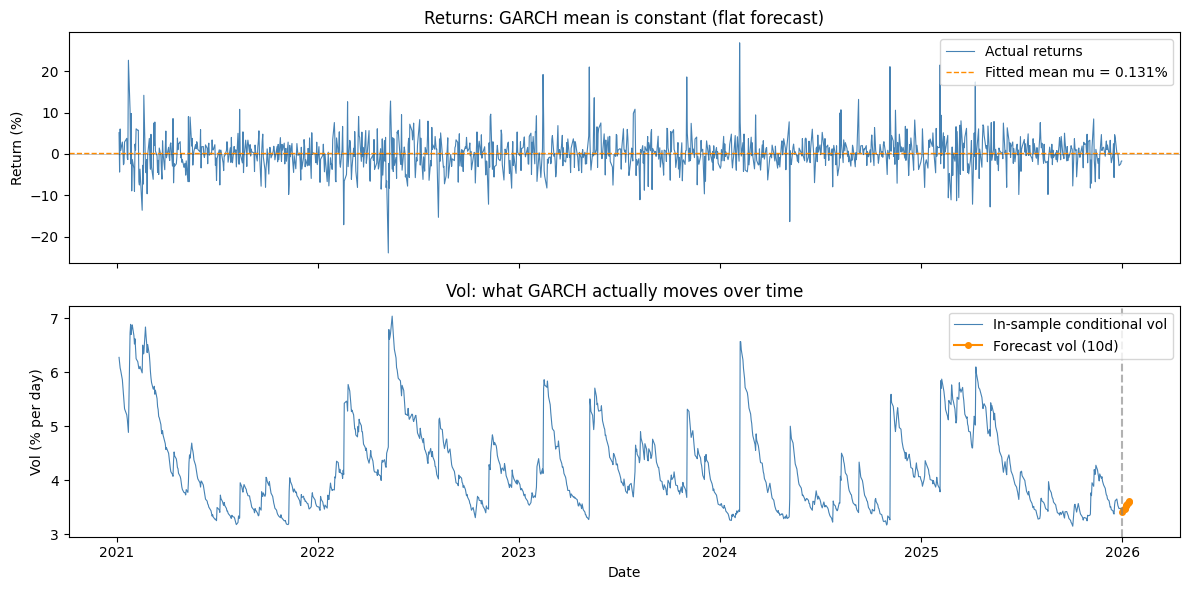

In [10]:
# Returns + GARCH vol (requires `result` from cell above)
# Constant-mean GARCH forecasts the same mu every day -> flat "return forecast" line (not useful to plot)
horizon = 10
plot_df = returns_df.dropna(subset=['Log Return']).copy()
dates = plot_df['Date']
r_hist = plot_df['Log Return'] * 100
cond_vol = result.conditional_volatility  # in-sample vol (% per day), same units as r

fc = result.forecast(horizon=horizon)
fc_vol = np.sqrt(fc.variance.iloc[-1].values)
last_date = dates.iloc[-1]
fc_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=horizon, freq='B')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates, r_hist, color='steelblue', linewidth=0.8, label='Actual returns')
axes[0].axhline(result.params['mu'], color='darkorange', linestyle='--', linewidth=1,
                label=f"Fitted mean mu = {result.params['mu']:.3f}%")
axes[0].axhline(0, color='black', linewidth=0.5, alpha=0.3)
axes[0].set_ylabel('Return (%)')
axes[0].set_title('Returns: GARCH mean is constant (flat forecast)')
axes[0].legend(loc='upper right')

axes[1].plot(dates, cond_vol, color='steelblue', linewidth=0.8, label='In-sample conditional vol')
axes[1].plot(fc_dates, fc_vol, color='darkorange', linewidth=1.5, marker='o', markersize=4,
             label=f'Forecast vol ({horizon}d)')
axes[1].axvline(last_date, color='gray', linestyle='--', alpha=0.6)
axes[1].set_ylabel('Vol (% per day)')
axes[1].set_xlabel('Date')
axes[1].set_title('Vol: what GARCH actually moves over time')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()